## 1. Install


In [1]:
!pip install -q ultralytics roboflow pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 691.3 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 63.7 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.4 MB/s eta 0:00:00


## 2. Imports

In [2]:
import os, glob, yaml, shutil
from collections import Counter, defaultdict
from getpass import getpass
import matplotlib.pyplot as plt
from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


## 3. Roboflow login

In [3]:
!pip install roboflow

In [4]:
rf = Roboflow(api_key="Q1FQoXMlwdOFvth4FMlY")
project = rf.workspace("noora-hussain-s-workspace").project("ecovision-quw28")
version = project.version(2)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to EcoVision-2 in yolo26:: 100%|██████████| 63639/63639 [00:14<00:00, 4401.47it/s] 


## 4. Download

In [5]:
DATASET_DIR = dataset.location
yaml_path = os.path.join(DATASET_DIR,"data.yaml")
print(DATASET_DIR)

/kaggle/working/EcoVision-2


## 5. Check classes

In [6]:
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]
print(class_names)

['General Waste', 'Glass', 'Metals', 'Paper', 'Plastics']


## 6. Dataset counts

In [7]:
for split in ["train", "valid", "test"]:
    print(split, ":", len(glob.glob(f"{DATASET_DIR}/{split}/images/*")))

train : 28182
valid : 2548
test : 1087


## 7. Object counts


In [8]:
def names_list(names):
    if isinstance(names, dict):
        return [names.get(i, names.get(str(i))) for i in range(len(names))]
    return list(names)

class_list = names_list(class_names)
class_counts = Counter()
images_per_class = defaultdict(set)
total_images = 0

for split in ["train", "valid", "test"]:
    total_images += len(glob.glob(f"{DATASET_DIR}/{split}/images/*"))

    for label_file in glob.glob(f"{DATASET_DIR}/{split}/labels/*.txt"):
        seen = set()

        for line in open(label_file):
            parts = line.split()
            if not parts:
                continue
            cid = int(parts[0])
            class_counts[cid] += 1
            seen.add(cid)

        for cid in seen:
            images_per_class[cid].add(label_file)

total_objects = sum(class_counts.values())

print("Total images:", total_images)
print("Total objects:", total_objects)
print("Average objects/image:", round(total_objects / total_images, 2))

for i, name in enumerate(class_list):
    print(f"{name}: {class_counts[i]} objects | {len(images_per_class[i])} images")

Total images: 31817
Total objects: 50098
Average objects/image: 1.57
General Waste: 9107 objects | 5334 images
Glass: 9079 objects | 6400 images
Metals: 12518 objects | 6037 images
Paper: 9481 objects | 6194 images
Plastics: 9913 objects | 6612 images


## 8. Class chart

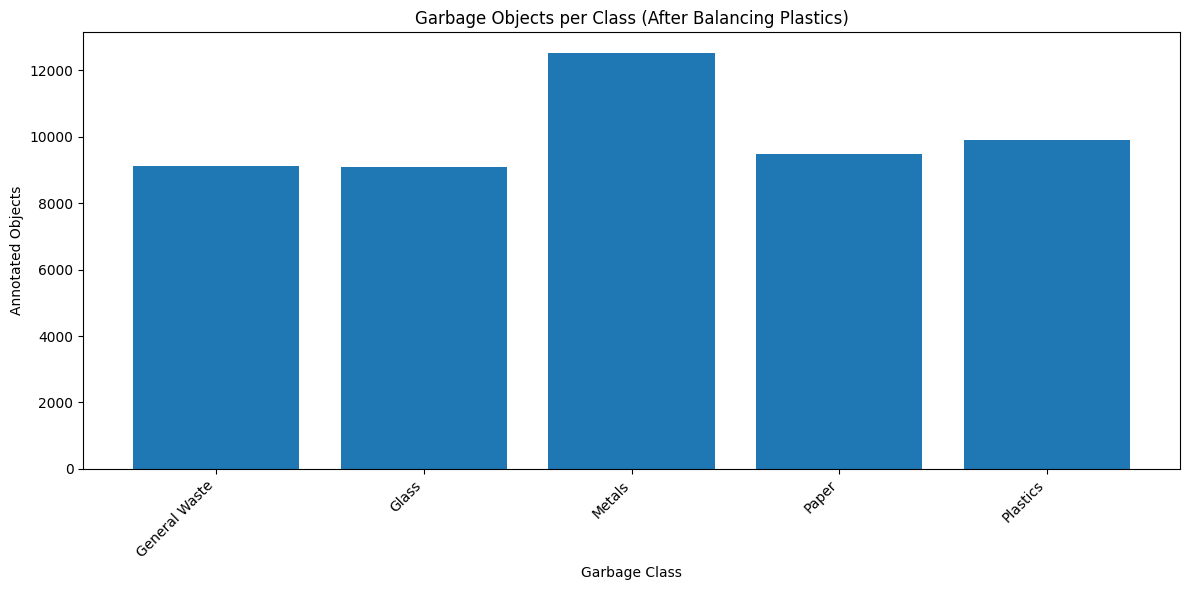

In [9]:
counts = [class_counts[i] for i in range(len(class_list))]

plt.figure(figsize=(12, 6))
plt.bar(class_list, counts)
plt.xlabel("Garbage Class")
plt.ylabel("Annotated Objects")
plt.title("Garbage Objects per Class (After Balancing Plastics)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Baseline


image 1/1 /kaggle/working/EcoVision-2/test/images/292998083_439993927757650_8074935195215621746_n_jpeg_jpg.rf.f1fe58314fbdc528ebfd1f6097739349.jpg: 640x512 1 cup, 10.3ms
Speed: 85.4ms preprocess, 10.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 512)


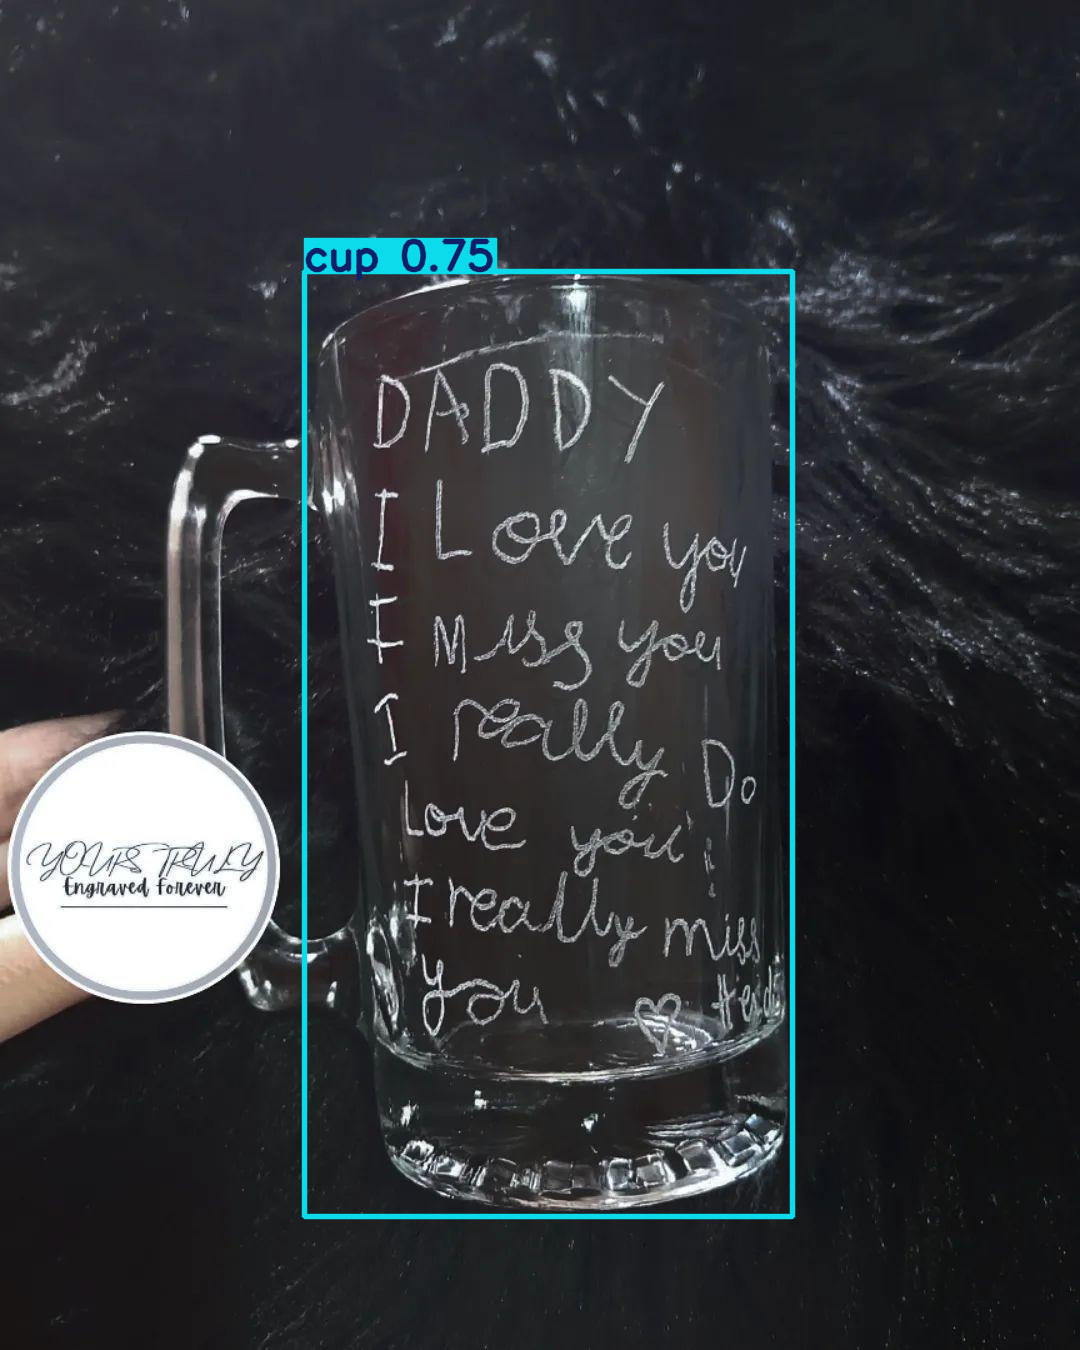

In [10]:
model = YOLO("yolo26n.pt")

test_images = glob.glob(f"{DATASET_DIR}/test/images/*")
if not test_images:
    raise ValueError("No test images found.")

baseline = model(test_images[0])
baseline[0].show()

## 10. Train with early stopping


In [11]:
yaml_path = os.path.join(DATASET_DIR, "data.yaml")

shutil.rmtree('/kaggle/working/EcoVision-2/v1', ignore_errors=True)

model = YOLO("yolo26n.pt")

model.train(      
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=15,
    cache=True,
    project="/kaggle/working/EcoVision-2",
    name="v1"
)

Ultralytics 8.4.135 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/EcoVision-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1, nbs=64, nms=False, op

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


      2/100      3.39G      1.354      2.294    0.01738         24        640: 100% ━━━━━━━━━━━━ 1737/1737 4.8it/s 5:590.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 6.9it/s 11.5s0.1s
                   all       2505       3824      0.598      0.365      0.392      0.286

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      3/100      3.39G       1.49      2.297    0.01974         23        640: 100% ━━━━━━━━━━━━ 1737/1737 5.0it/s 5:490.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 7.0it/s 11.3s0.1s
                   all       2505       3824        0.5      0.315      0.321      0.213

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      4/100      3.39G       1.56      2.347    0.02067         25        640: 100% ━━━━━━━━━━━━ 1737/1737 5.0it/s 5:460.2ss
                 Class   

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c2855cc98b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

## 11. Load best model

In [17]:
best_path = "/kaggle/working/EcoVision-2/v1/weights/best.pt"
v1_model = YOLO(best_path)
print(v1_model.names)

{0: 'General Waste', 1: 'Glass', 2: 'Metals', 3: 'Paper', 4: 'Plastics'}


## 12. Evaluate

In [18]:
metrics = v1_model.val(data=yaml_path, split="test")

print("Precision:", round(metrics.box.mp, 4))
print("Recall:", round(metrics.box.mr, 4))
print("mAP50:", round(metrics.box.map50, 4))
print("mAP50-95:", round(metrics.box.map, 4))


Ultralytics 8.4.135 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1558.8±1051.5 MB/s, size: 251.2 KB)
val: Scanning /kaggle/working/EcoVision-2/test/labels.cache... 1087 images, 165 backgrounds, 19 corrupt: 100% ━━━━━━━━━━━━ 1087/1087 350.7Mit/s 0.0s
val: /kaggle/working/EcoVision-2/test/images/20220615_093855_jpg.rf.18b5867c553eb32c6bd8fb4f17f8a132.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /kaggle/working/EcoVision-2/test/images/20220615_094608_jpg.rf.22287a99e759e7a09475601fa29793e6.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /kaggle/working/EcoVision-2/test/images/20220615_144804_jpg.rf.ee9710f9c82e40dc96931c355268077d.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /kaggle/working/EcoVision-2/test/images/20220615_145023_jpg.rf.1ea63ec1

## 13. Per-class mAP50-95


In [19]:
for name, score in zip(v1_model.names.values(), metrics.box.maps):
    print(name, ":", round(float(score), 4))

General Waste : 0.5033
Glass : 0.7691
Metals : 0.479
Paper : 0.7494
Plastics : 0.4687


## 14. Test images


0: 640x640 (no detections), 4.8ms
1: 640x640 1 Paper, 4.8ms
2: 640x640 1 Glass, 4.8ms
3: 640x640 (no detections), 4.8ms
4: 640x640 1 Glass, 4.8ms
5: 640x640 2 Papers, 4.8ms
6: 640x640 1 Paper, 4.8ms
7: 640x640 1 Plastics, 4.8ms
8: 640x640 (no detections), 4.8ms
9: 640x640 2 Papers, 4.8ms
Speed: 1.8ms preprocess, 4.8ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


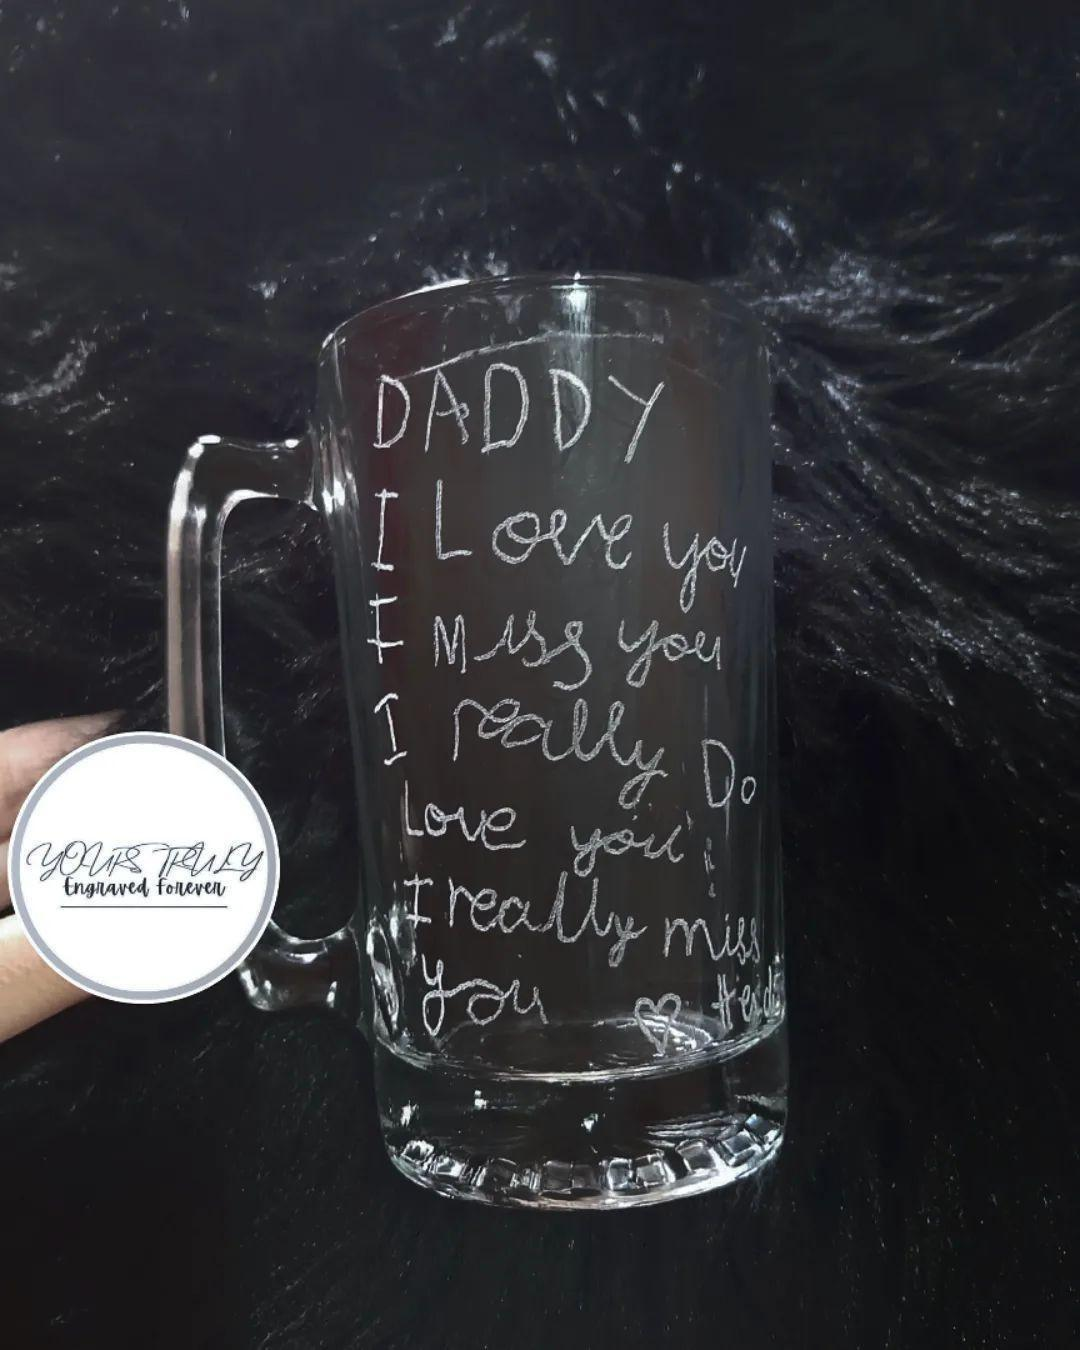

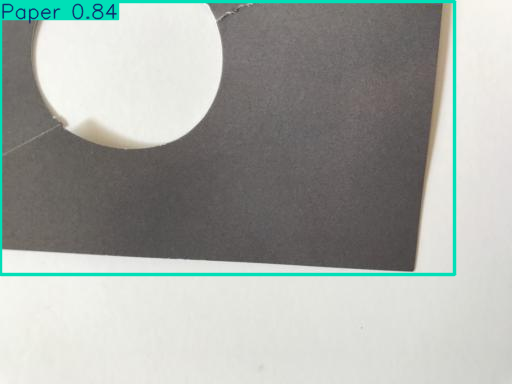

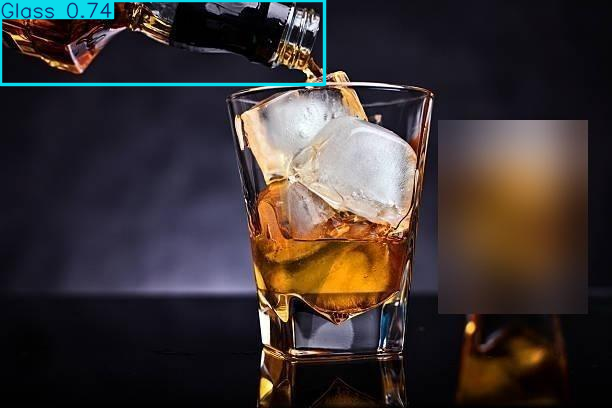

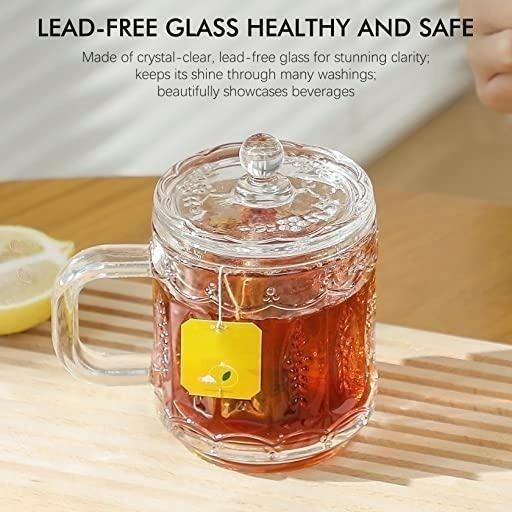

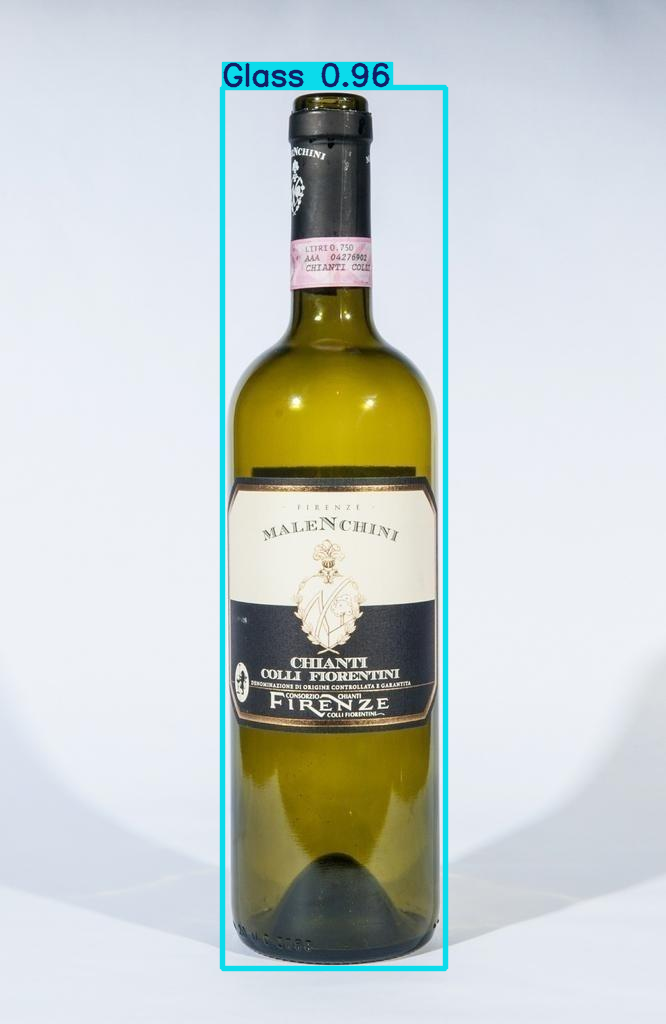

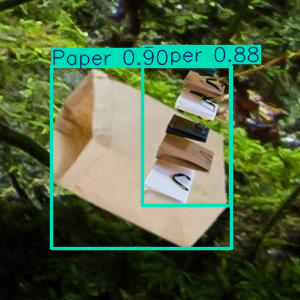

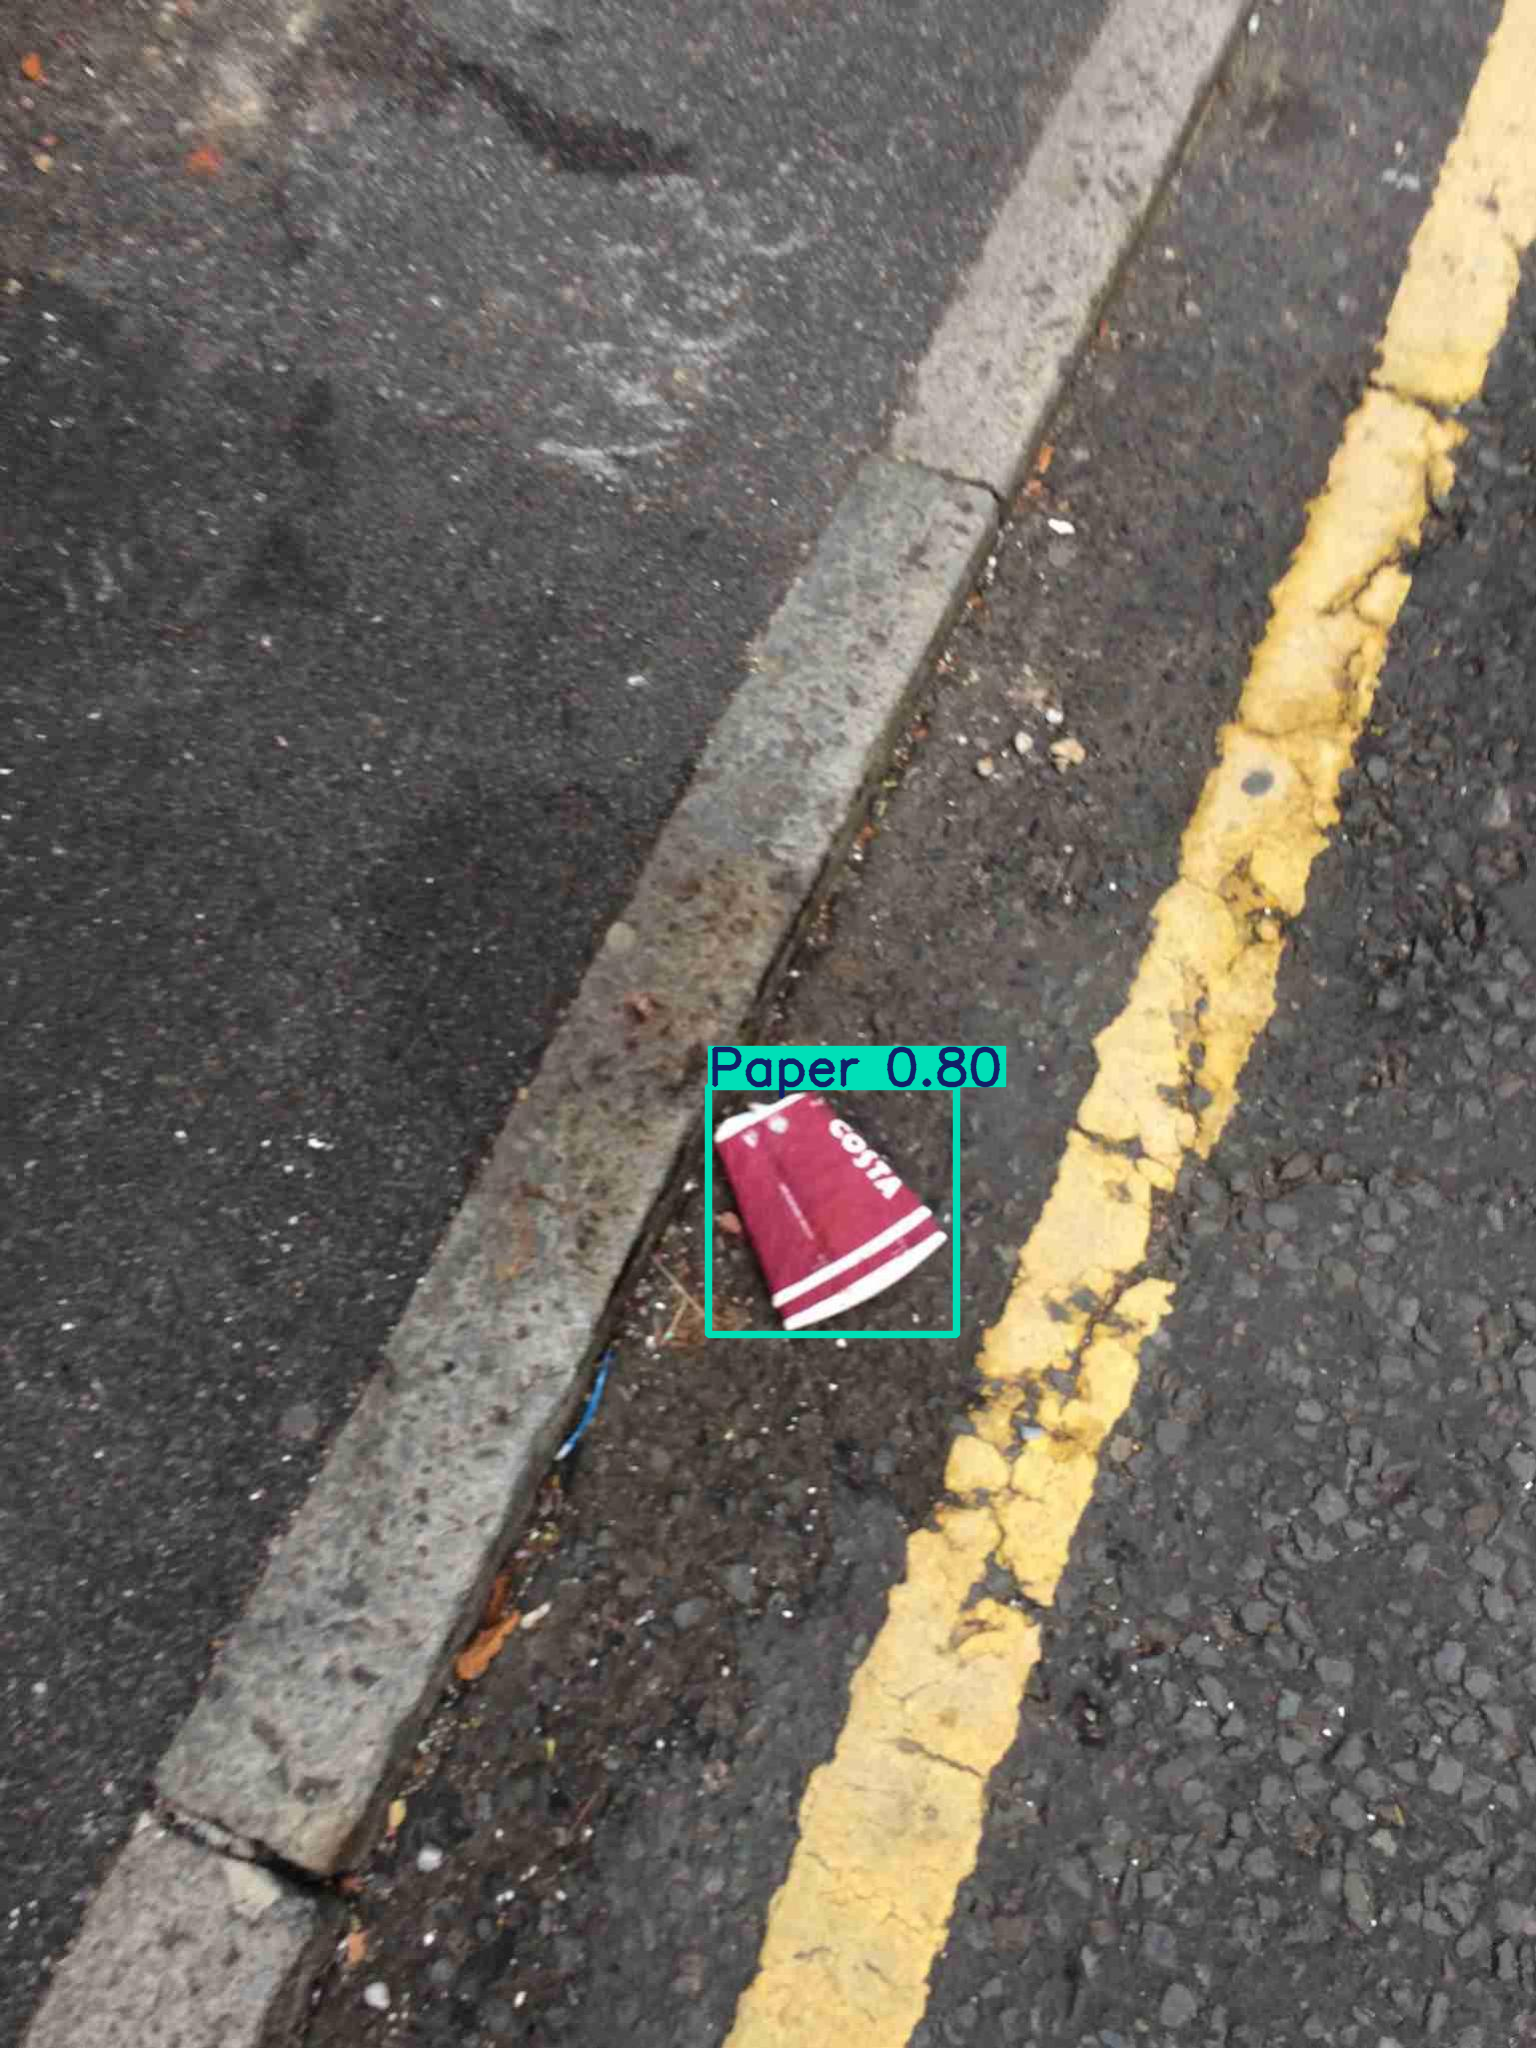

In [ ]:
results = v1_model(test_images[:10], conf=0.25)

for result in results:

    result.show()

## 15. Confusion_matrix

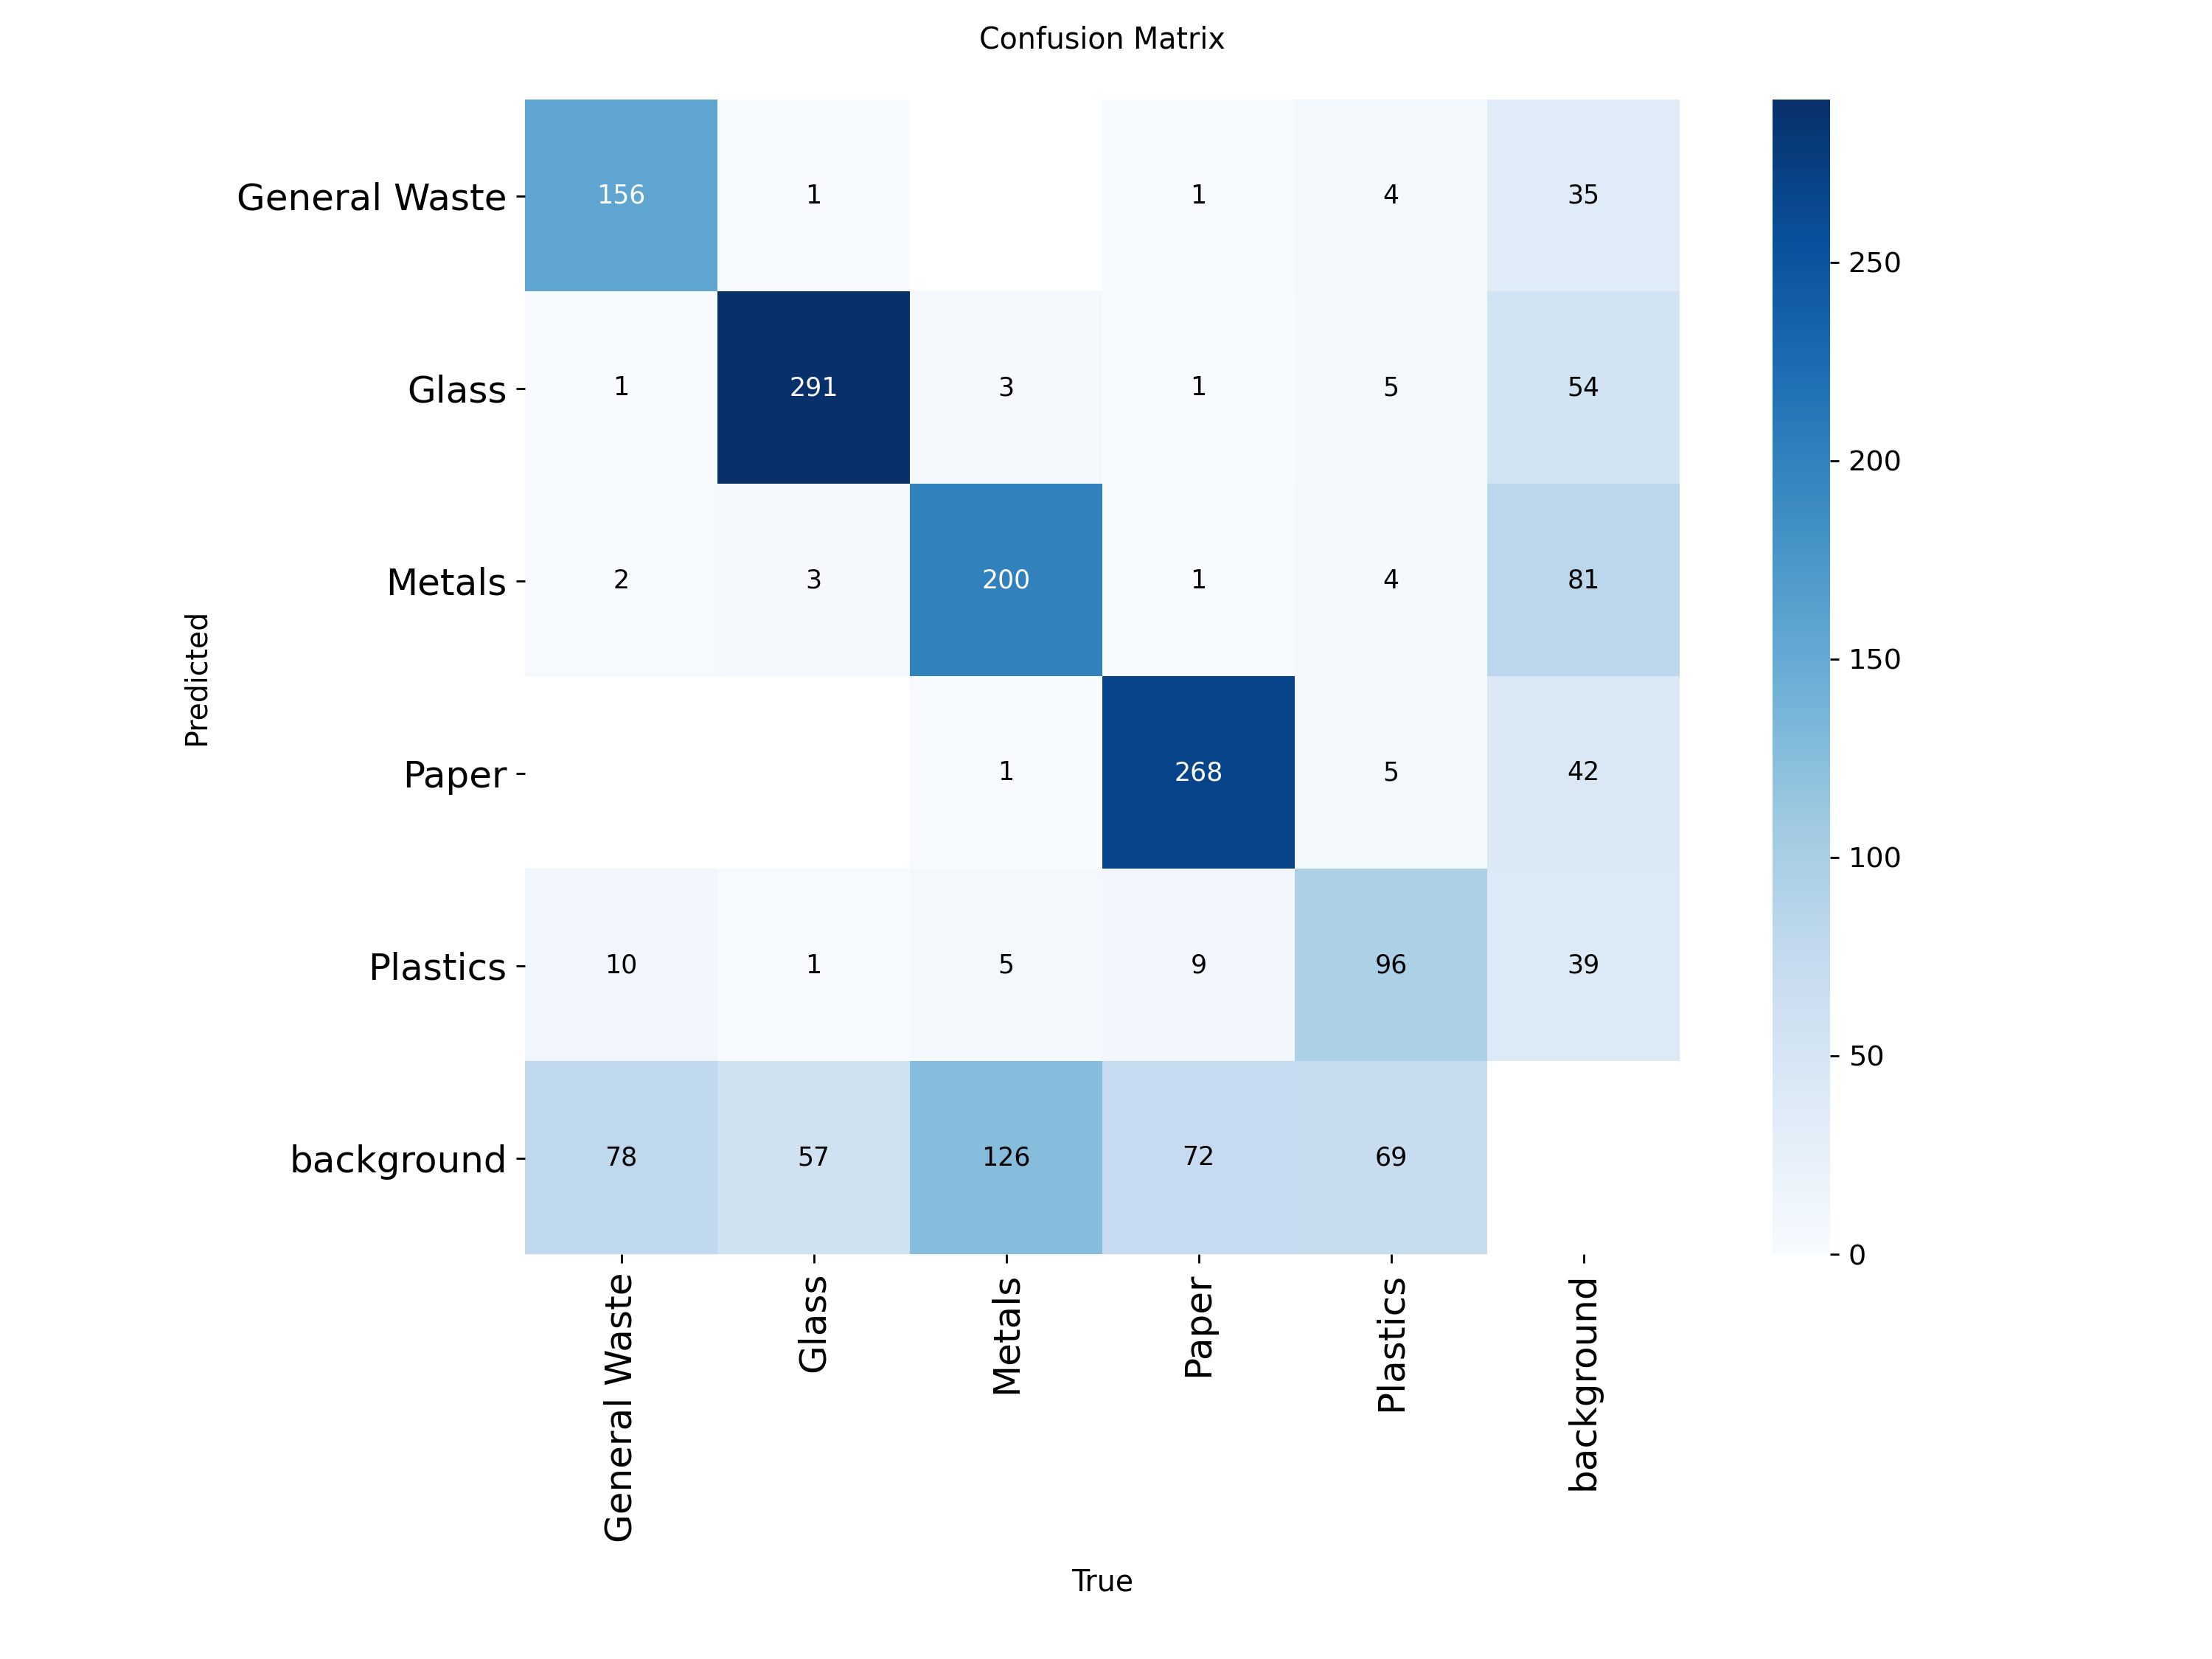

In [22]:
from IPython.display import Image, display

display(Image(
    filename="/kaggle/working/runs/detect/val/confusion_matrix.png",
    width=800
))